# Module 4 - Class 4: SVM vs KNN Showdown

**Dataset:** Telco Customer Churn  
**Objective:** Compare SVM and KNN classifiers on churn prediction, measure accuracy, F1, and training time.

### What you will learn
- Support Vector Machines with RBF kernel
- K-Nearest Neighbors with different K values
- Why feature scaling is critical for distance-based models
- How to benchmark training time

---

## 0. Setup

In [4]:
import pandas as pd  # Import pandas library for tabular data manipulation, ingestion, and structured analysis
import numpy as np  # Import numpy library for performant array processing, vectorization, and mathematical foundations
import matplotlib.pyplot as plt  # Import matplotlib.pyplot for engineering basic figures, coordinates, and static visualizations
import seaborn as sns  # Import seaborn library for rendering high-level, advanced statistical plots on top of matplotlib
import time  # Import the built-in time module to benchmark execution intervals and capture processor runtimes
from sklearn.model_selection import train_test_split  # Import train_test_split to isolate records into independent training and validation partitions
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Import tools to scale continuous ranges to unit variance and extract binary categories from string flags
from sklearn.compose import ColumnTransformer  # Import ColumnTransformer to bind specific preprocessing branches to specified column names or indexes
from sklearn.pipeline import Pipeline  # Import Pipeline to sequence multiple feature transformations and an estimator into an atomized object
from sklearn.impute import SimpleImputer  # Import SimpleImputer to resolve empty, missing, or corrupt records using targeted statistical imputation
from sklearn.svm import SVC  # Import Support Vector Classifier (SVC) to construct high-dimensional, kernelized boundary separations
from sklearn.neighbors import KNeighborsClassifier  # Import KNeighborsClassifier to implement instance-based, local neighborhood votes

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report
)  # Import standard classification evaluators to cross-examine precision, balance, and true rate targets

import warnings  # Import warnings module to capture, intercept, or modify internal package alert criteria

warnings.filterwarnings('ignore')  # Quiet the active warning system to isolate console text outputs from standard library noise

print("Setup complete.")  # Print a clean text message to verify that all core and modeling packages loaded successfully

Setup complete.


## 1. Load and Preprocess Data

In [5]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"  # Store the source URL for the IBM Telco customer churn dataset
df = pd.read_csv(url)  # Fetch and load the CSV dataset from the remote repository into a Pandas DataFrame

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # Force conversion of 'TotalCharges' to numeric, turning blank strings into NaN values

# Standardize multi-level columns
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']  # Specify columns containing the redundant 'No internet service' category
for col in replace_cols:  # Iterate over each internet service column in the list
    df[col] = df[col].replace('No internet service', 'No')  # Collapse the redundant internet service category into a standard 'No' response
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')  # Collapse the redundant phone service category into a standard 'No' response

# Target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)  # Map the 'Yes' and 'No' text targets into machine-readable binary 1s and 0s

X = df.drop(['customerID', 'Churn'], axis=1)  # Drop identifier and target columns to isolate the matrix of independent features
y = df['Churn']  # Isolate the binary encoded churn column as the dependent target variable

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()  # Collect names of all columns containing discrete or continuous numerical values
cat_cols = X.select_dtypes(include='object').columns.tolist()  # Collect names of all columns containing text objects or categorical labels

# Preprocessing with StandardScaler (required for SVM and KNN)
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])  # Setup a numeric workflow to impute missing entries with the median and scale features to a mean of 0 and variance of 1

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])  # Setup a categorical workflow to impute missing entries with the mode and convert strings to binary indicators using dummy encoding

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, cat_cols)
])  # Map the numeric and categorical pipeline workflows to their corresponding feature lists

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)  # Split data into 80/20 train/test fractions, maintaining identical target class proportions in both sets

# Transform
X_train_proc = preprocessor.fit_transform(X_train)  # Learn scaling and imputation parameters from the training set and transform the training data matrix
X_test_proc = preprocessor.transform(X_test)  # Apply the learned training transformations to the testing data matrix to prevent data leakage

print(f"Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")  # Output the final structural dimensions of both the processed training and testing arrays
print(f"\nWhy StandardScaler matters:")  # Print a section header introducing the mathematical justification for feature scaling
print(f"  SVM uses distances in kernel space — unscaled features dominate.")  # Display text explaining how unscaled features distort support vector margin maximization boundaries
print(f"  KNN computes Euclidean distance — same problem.")  # Display text explaining how unscaled features falsely distort distance metrics and neighbor selections

Train: (5634, 23), Test: (1409, 23)

Why StandardScaler matters:
  SVM uses distances in kernel space — unscaled features dominate.
  KNN computes Euclidean distance — same problem.


## 2. SVM with RBF Kernel

In [6]:
start = time.time()  # Record the current system timestamp to measure the beginning of the model training phase
svm = SVC(kernel='rbf', random_state=42)  # Initialize a Support Vector Classifier using a Radial Basis Function kernel to capture non-linear decision boundaries
svm.fit(X_train_proc, y_train)  # Train the SVM model on the preprocessed training dataset matrix
svm_train_time = time.time() - start  # Calculate total execution duration by subtracting the start timestamp from the current time

y_pred_svm = svm.predict(X_test_proc)  # Generate discrete binary class labels (0 or 1) for the processed testing dataset

svm_acc = accuracy_score(y_test, y_pred_svm)  # Compute the overall accuracy score representing the proportion of correct classifications on the test set
svm_f1 = f1_score(y_test, y_pred_svm)  # Compute the balanced F1 score representing the harmonic mean of precision and recall for the positive class

print(f"SVM (RBF) Results:")  # Print a section header indicating the specific classifier configuration being evaluated
print(f"  Accuracy:      {svm_acc:.4f}")  # Display the calculated testing accuracy formatted to 4 decimal places
print(f"  F1 Score:      {svm_f1:.4f}")  # Display the calculated testing F1 score formatted to 4 decimal places
print(f"  Training Time: {svm_train_time:.3f}s")  # Output the exact wall-clock training time duration rounded to 3 decimal places
print()  # Print an empty line for visual spacing in the terminal console output
print(classification_report(y_test, y_pred_svm, target_names=['No Churn', 'Churn']))  # Generate and display a structured classification report with class-specific precision, recall, and support metrics

SVM (RBF) Results:
  Accuracy:      0.7921
  F1 Score:      0.5471
  Training Time: 2.383s

              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



## 3. KNN (K=5)

In [7]:
start = time.time()  # Record the current system timestamp to measure the beginning of the model training phase
knn5 = KNeighborsClassifier(n_neighbors=5)  # Initialize a K-Nearest Neighbors classifier configured to evaluate the 5 closest records using default Minkowski distance
knn5.fit(X_train_proc, y_train)  # Map the training data matrix to an internal tree structure for fast spatial neighborhood queries
knn5_train_time = time.time() - start  # Calculate total training configuration duration by subtracting the start timestamp from the current time

y_pred_knn5 = knn5.predict(X_test_proc)  # Generate discrete binary class labels (0 or 1) for the test set based on majority neighborhood votes

knn5_acc = accuracy_score(y_test, y_pred_knn5)  # Compute the overall accuracy score representing the proportion of correct classifications on the test set
knn5_f1 = f1_score(y_test, y_pred_knn5)  # Compute the balanced F1 score representing the harmonic mean of precision and recall for the positive class

print(f"KNN (K=5) Results:")  # Print a section header indicating the specific neighbor count configuration being evaluated
print(f"  Accuracy:      {knn5_acc:.4f}")  # Display the calculated testing accuracy formatted to 4 decimal places
print(f"  F1 Score:      {knn5_f1:.4f}")  # Display the calculated testing F1 score formatted to 4 decimal places
print(f"  Training Time: {knn5_train_time:.3f}s")  # Output the exact wall-clock training configuration duration rounded to 3 decimal places
print()  # Print an empty line for visual spacing in the terminal console output
print(classification_report(y_test, y_pred_knn5, target_names=['No Churn', 'Churn']))  # Generate and display a structured classification report with class-specific precision, recall, and support metrics

KNN (K=5) Results:
  Accuracy:      0.7658
  F1 Score:      0.5612
  Training Time: 0.006s

              precision    recall  f1-score   support

    No Churn       0.84      0.84      0.84      1035
       Churn       0.56      0.56      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



## 4. KNN with Different K Values

In [8]:
results = []  # Initialize an empty list to accumulate performance metrics for the different neighbor hyperparameter configurations

for k in [3, 5, 10]:  # Iterate sequentially through a list of distinct cluster neighborhood values to perform a basic hyperparameter sweep
    start = time.time()  # Record the beginning system timestamp for the current neighborhood configuration's training phase
    knn = KNeighborsClassifier(n_neighbors=k)  # Instantiate a new K-Nearest Neighbors classifier object utilizing the current k value
    knn.fit(X_train_proc, y_train)  # Fit the model by mapping the high-dimensional spatial coordinates of the training data matrix
    train_time = time.time() - start  # Compute the total training indexing duration by evaluating the delta against the start timestamp

    y_pred = knn.predict(X_test_proc)  # Generate discrete binary class predictions (0 or 1) for the processed validation test dataset
    results.append({
        'Model': f'KNN (K={k})',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Train Time (s)': train_time
    })  # Append a comprehensive performance logging dictionary mapping the hyperparameter variant to its evaluated test metrics

knn_df = pd.DataFrame(results).round(4)  # Aggregate the list of iteration dictionaries into a structured DataFrame and round all numeric evaluations to 4 decimal places
print(knn_df.to_string(index=False))  # Print the consolidated hyperparameter comparison table to the console as a clean text block without row index values

     Model  Accuracy     F1  Train Time (s)
 KNN (K=3)    0.7566 0.5445          0.0013
 KNN (K=5)    0.7658 0.5612          0.0008
KNN (K=10)    0.7764 0.5374          0.0009


## 5. Full Comparison Table

In [9]:
# Collect all results
all_results = []  # Initialize an empty list to aggregate results across both Support Vector Machine and K-Nearest Neighbors runs

# SVM
all_results.append({
    'Model': 'SVM (RBF)',
    'Accuracy': svm_acc,
    'F1': svm_f1,
    'Train Time (s)': svm_train_time
})  # Append the pre-calculated performance metrics and training duration for the RBF kernel SVM model

# KNN variants
for k in [3, 5, 10]:  # Iterate sequentially through the selected neighborhood sizes to evaluate each KNN configuration
    knn = KNeighborsClassifier(n_neighbors=k)  # Instantiate a K-Nearest Neighbors classifier matching the current neighbor count
    start = time.time()  # Capture the baseline timestamp immediately prior to executing the spatial indexing phase
    knn.fit(X_train_proc, y_train)  # Map the spatial positions of the high-dimensional training feature matrix
    t = time.time() - start  # Calculate the model indexing duration by evaluating the delta against the start timestamp
    y_pred = knn.predict(X_test_proc)  # Generate discrete binary class label predictions (0 or 1) for the processed test instances
    all_results.append({
        'Model': f'KNN (K={k})',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Train Time (s)': t
    })  # Append a comprehensive evaluation dictionary detailing the unique KNN variant metrics to the results collector

comparison = pd.DataFrame(all_results).round(4)  # Construct a unified data summary matrix from the accumulated list and round all floating points to 4 decimal places
print("=" * 55)  # Print a top decorative boundary separator line exactly 55 characters wide for clean visual staging
print("       SVM vs KNN — Final Comparison")  # Print an aligned section header label to contextualize the benchmarking table
print("=" * 55)  # Print an inner decorative boundary separator line exactly 55 characters wide to split the header from data rows
print(comparison.to_string(index=False))  # Output the final tabular comparison data matrix formatted cleanly as raw text without row indices
print("=" * 55)  # Print a bottom decorative boundary separator line exactly 55 characters wide to encapsulate the console output layout

       SVM vs KNN — Final Comparison
     Model  Accuracy     F1  Train Time (s)
 SVM (RBF)    0.7921 0.5471          2.3826
 KNN (K=3)    0.7566 0.5445          0.0046
 KNN (K=5)    0.7658 0.5612          0.0028
KNN (K=10)    0.7764 0.5374          0.0007


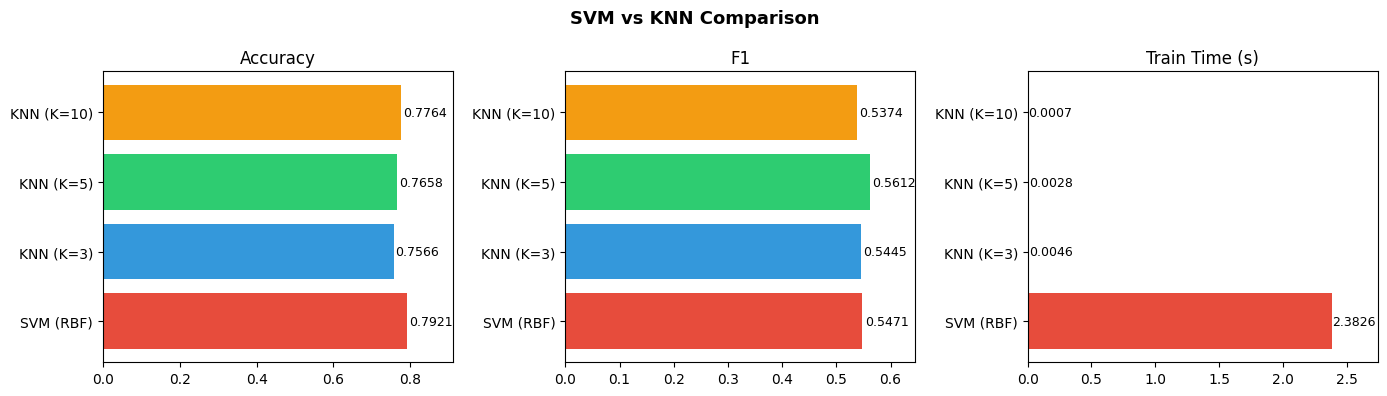

In [11]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))  # Initialize a grid of 1 row and 3 columns of subplots with a specified overall canvas dimensions

for i, metric in enumerate(['Accuracy', 'F1', 'Train Time (s)']):  # Loop sequentially through each evaluation metric alongside its positional index
    axes[i].barh(comparison['Model'], comparison[metric], color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])  # Generate a horizontal bar chart on the current subplot utilizing distinct hex colors for each model row
    axes[i].set_title(metric)  # Assign the current metric name as the descriptive header label for the isolated subplot axis
    axes[i].set_xlim(0, max(comparison[metric]) * 1.15)  # Scale the horizontal axis upper limit to 115% of the maximum value to provide sufficient margin for text annotations
    for j, v in enumerate(comparison[metric]):  # Iterate through the rows of the current metric column to isolate values and index positions
        axes[i].text(v + 0.005, j, f'{v:.4f}', va='center', fontsize=9)  # Place a text label displaying the rounded score value next to its corresponding bar plot element

plt.suptitle('SVM vs KNN Comparison', fontsize=13, fontweight='bold')  # Construct an overall, bold main title centered at the top of the entire subplots figure layout
plt.tight_layout()  # Automatically recalculate padding and bounding margins around subplots to minimize overlapping chart text labels
plt.show()  # Render and display the final comparative multi-panel chart on screen, clearing the current figure canvas state

## 6. TODO: Which Model Would You Choose?

Based on the comparison table above, answer these questions (3-5 sentences):

1. Which model gives the best F1 score? Which gives the best accuracy?
2. How does training time differ between SVM and KNN? Why?
3. If you had to deploy one model for a Telco company, which would you pick and why?
4. What happens to KNN performance as K increases? Why?

**TODO: Your answer here**

*Write your answer in this cell.*


In [ ]:
# 1.  **Best F1 Score and Accuracy:** The SVM (RBF) model gives the best accuracy at 0.7921. The KNN (K=5) model gives the best F1 score at 0.5612, closely followed by SVM (RBF) at 0.5471.
# 2.  **Training Time Difference:** There's a significant difference in training time. SVM (RBF) takes 2.3826 seconds, whereas all KNN models train in milliseconds (e.g., KNN K=10 in 0.0007 seconds). This is because KNN is a 'lazy learner' — its training phase primarily involves storing the data, with computations occurring during prediction. SVM, however, involves solving a complex optimization problem to find the optimal hyperplane, especially with an RBF kernel, which is computationally more intensive.
# 3.  **Model Choice for Telco Company:** For a Telco company, I would lean towards the **SVM (RBF)** model. While KNN (K=5) has a marginally better F1 score for churn, SVM offers higher overall accuracy (0.7921 vs 0.7658). Given that churn prediction often involves balancing false positives and false negatives, and assuming a single training run, the superior accuracy of SVM is a strong advantage. Its training time of 2.38 seconds is also acceptable for most business scenarios where retraining might not be daily.
# 4.  **KNN Performance as K Increases:** As K increases in KNN (from 3 to 10), the accuracy generally shows a slight increase (0.7566 to 0.7764). However, the F1 score doesn't follow a clear monotonic trend; it increases from K=3 to K=5 (0.5445 to 0.5612) and then decreases at K=10 (0.5374). Increasing K makes the decision boundary smoother and less sensitive to noise in individual data points (reducing variance). However, if K becomes too large, the model might oversimplify the underlying patterns and miss local structures (increasing bias), which can lead to a decrease in performance metrics like F1 score.

---
## Summary

| Concept | Details |
|---------|--------|
| SVM | Finds the optimal hyperplane that maximizes margin between classes |
| RBF Kernel | Maps data to higher dimensions — handles non-linear boundaries |
| KNN | Classifies based on majority vote of K nearest neighbors |
| Feature Scaling | Both SVM and KNN are distance-based — scaling is mandatory |
| K value | Low K = more noise sensitivity, High K = smoother but may miss patterns |
| Training Time | SVM trains slow, predicts fast. KNN trains instant, predicts slow (lazy learner). |